# 1D OSIRIS Photon Kinetics Tests and Analysis Notebook

blah blah blah

## Needed Imports

In [7]:
import os
import re
import glob
import h5py
import numpy as np
import matplotlib.pyplot as plt

from readers import osiris_load_density, osiris_load_efield

## Plot a Snapshot of the Plasma Density and Laser Pulse

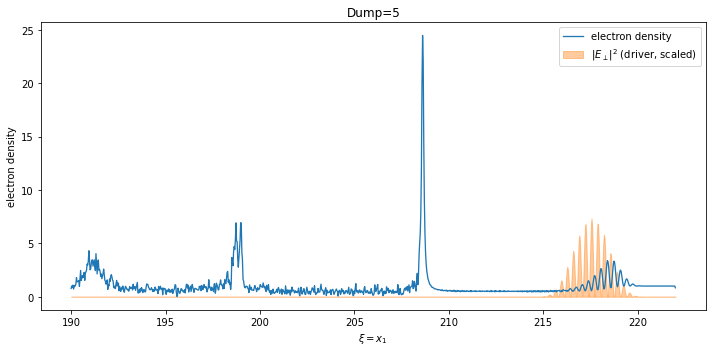

In [27]:
dump=5
plasma_dat, plasma_ax = osiris_load_density(dump=dump, species="electrons", path="./")

e1, _ = osiris_load_efield(dump=dump, component="1", path="./")
e2, _ = osiris_load_efield(dump=dump, component="2", path="./")
intensity = e2**2

# Scale the driver envelope so it's not insanely huge compared to the density
density_scale = np.abs(data).max()
intensity_scaled = intensity / intensity.max() * density_scale

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(axes["x1"], np.abs(plasma_dat), color="tab:blue", lw=1.3, label="electron density")
ax.fill_between(axes["x1"], intensity_scaled, color="tab:orange", alpha=0.4,
                 label=r"$|E_\perp|^2$ (driver, scaled)")

ax.set_xlabel(r"$\xi = x_1$")
ax.set_ylabel("electron density")
ax.set_title(f"Dump={dump}")
ax.legend(loc="upper right")

fig.tight_layout()
plt.show()

## Create a Movie With a Series of Plots

In [24]:
# --- settings ---
dump_range = range(0, 20)  # Specify the frames you'd like to create plots for
frame_dir = "frames"       # Specify a directory you'd like to store the frames in

figsize = (10, 5)

# --- generate frames ---
os.makedirs(frame_dir, exist_ok=True)
frame_paths = []

for dump in dump_range:
    # Load all of the data you'd like to use (in this case, just the species -- electron -- data and E-field data)
    data, axes = osiris_load_density(dump=dump, species="electrons", path=path)
    e2, _ = osiris_load_efield(dump=dump, component="2", path=path)

    # Calculate the intensity of the laser pulse
    intensity = e2**2

    density_scale = np.abs(data).max()
    intensity_scaled = intensity / intensity.max() * density_scale

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(axes["x1"], np.abs(data), color="tab:blue", lw=1.3, label="electron density")
    ax.fill_between(axes["x1"], intensity_scaled, color="tab:orange", alpha=0.4,
                    label=r"$|E_\perp|^2$ (driver, scaled)")

    ax.set_xlabel(r"$\xi = x_1$")
    ax.set_ylabel("electron density")
    ax.set_title(f"Dump={dump}")
    ax.legend(loc="upper right")
    fig.tight_layout()

    frame_path = os.path.join(frame_dir, f"frame_{dump:06d}.png")
    fig.savefig(frame_path, dpi=120)
    plt.close(fig)

    frame_paths.append(frame_path)
    
    print(f"Frame {dump} completed...")

print(f"Saved {len(frame_paths)} frames to {frame_dir}/")

Frame 0 completed...
Frame 1 completed...
Frame 2 completed...
Frame 3 completed...
Frame 4 completed...
Frame 5 completed...
Frame 6 completed...
Frame 7 completed...
Frame 8 completed...
Frame 9 completed...
Frame 10 completed...
Frame 11 completed...
Frame 12 completed...
Frame 13 completed...
Frame 14 completed...
Frame 15 completed...
Frame 16 completed...
Frame 17 completed...
Frame 18 completed...
Frame 19 completed...
Saved 20 frames to frames/
